<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment No. 07: Decision Trees, Pruning and Overfitting
### Roll No: 24/CS/232

---

### **Aim:**
To implement a **Decision Tree Classifier**, study the effect of tree depth on model performance, identify **overfitting**, and apply **cost-complexity pruning** to obtain a suitable decision tree with a good balance between accuracy and model complexity.

### **Objectives:**
After completing this experiment, students will be able to:
1. Understand the working principle of a **Decision Tree Classifier**.
2. Understand how a decision tree recursively partitions the dataset.
3. Study **Gini Impurity** and **Entropy** as splitting criteria.
4. Train an **unrestricted/deep decision tree**.
5. Train a **shallow decision tree** and compare its performance with the deep tree.
6. Investigate the effect of `max_depth` on training and testing accuracy.
7. Identify **overfitting** using the train-test accuracy gap.
8. Understand the **bias-variance trade-off** in decision trees.
9. Apply **cost-complexity pruning** using `ccp_alpha`.
10. Select a suitable tree depth/pruning configuration based on accuracy and interpretability.

### **Pseudo Algorithm / Steps:**
1. **Start**.
2. **Load** the classification dataset (`Titanic-Dataset.csv`).
3. **Inspect** the dataset and identify the feature and target columns.
4. **Handle missing values** and encode categorical features.
5. **Divide** the dataset into training (70%) and testing (30%) sets.
6. **Predict** whether an unrestricted decision tree is likely to overfit.
7. **Train** an unrestricted Decision Tree Classifier.
8. **Train** a shallow tree with `max_depth=3`.
9. **Calculate** training and testing accuracy for both models.
10. **Compare** the train-test accuracy gap.
11. **Vary `max_depth`** from 1 to 14.
12. **Train** a separate decision tree for each depth.
13. **Calculate** training and testing accuracy at each depth.
14. **Plot** training and testing accuracy against tree depth.
15. **Identify** the depth at which the train-test gap begins to increase.
16. **Generate** the cost-complexity pruning path (`cost_complexity_pruning_path`).
17. **Obtain** candidate `ccp_alpha` values.
18. **Train** a pruned decision tree using a suitable `ccp_alpha`.
19. **Compare** the pruned tree with the unrestricted tree.
20. **Select** the final depth/pruning configuration based on generalisation and interpretability.
21. **Record** observations and conclusion.
22. **Stop**.

**1. Loading the Dataset & Identifying Features (Steps 1–3)**

* **Dataset:** Titanic Dataset hosted at GitHub (`Titanic-Dataset.csv`).
* **Target Column:** `Survived` (0 = Did not survive, 1 = Survived) $\rightarrow$ Binary Classification.
* **Feature Columns:**
  * *Numerical Features:* `Pclass` (ordinal class: 1st, 2nd, 3rd), `Age`, `SibSp` (# of siblings/spouses aboard), `Parch` (# of parents/children aboard), `Fare` (ticket price).
  * *Categorical Features:* `Sex` (male/female), `Embarked` (port of embarkation: C, Q, S).
  * *Identifier / High Cardinality Features to drop:* `PassengerId`, `Name`, `Ticket`, `Cabin`.

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# load the dataset from the repository URL
url = 'https://github.com/JyRaGa/CS303-Machine-Learning_Coursework/raw/refs/heads/main/datasets/Titanic-Dataset.csv'
df = pd.read_csv(url)

# drop identifier and high-cardinality/unstructured columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# inspect dataset information and first few records
print(f"Dataset Shape: {df.shape}")
df.info()
df.head()

Dataset Shape: (891, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


**2. Data Preprocessing & Train-Test Split (Steps 4–5)**

* **Missing Value Imputation:**
  * `Age`: Imputed with median to preserve distribution without outlier distortion.
  * `Embarked`: Imputed with mode (most frequent port `'S'`).
  * `Fare`: Imputed with median.
* **Categorical Encoding:** One-hot encoding applied on `Sex` (`Sex_male`) and `Embarked` (`Embarked_Q`, `Embarked_S`) using `drop_first=True` to avoid multicollinearity.
* **Dataset Partitioning:** Divided into **70% Training** and **30% Testing** sets with fixed `random_state=42` for reproducible benchmarking.

In [ ]:
# handle missing values: median for numerical, mode for categorical
df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# one-hot encode categorical features ('Sex', 'Embarked')
df_encoded = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True)

# separate features and target
X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

# split into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Feature matrix shape: {X.shape}")
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")
print(f"Encoded features: {list(X.columns)}")

Feature matrix shape: (891, 8)
Training samples: 623, Testing samples: 268
Encoded features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


**3. Deep vs Shallow Decision Tree: Overfitting Hypothesis & Evaluation (Steps 6–10)**

* **Hypothesis (Step 6):** An unrestricted decision tree continues partitioning until all terminal leaves are 100% pure (impurity = 0) or contain fewer samples than `min_samples_split`. As a result, it memorizes individual sample quirks, noise, and outliers in the training set. This leads to **severe overfitting (high variance)**: near-perfect training accuracy but substantially lower testing accuracy.
* **Shallow Regularization (Step 8):** Constraining tree depth (`max_depth=3`) prevents over-partitioning, forcing the model to capture only coarse, dominant decision boundaries (e.g., gender, class, fare), yielding **better generalization** on unseen test data.

In [ ]:
# train an unrestricted decision tree classifier
dt_deep = DecisionTreeClassifier(random_state=42)
dt_deep.fit(X_train, y_train)

# train a shallow decision tree with max_depth=3
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

# evaluate accuracies
train_acc_deep = accuracy_score(y_train, dt_deep.predict(X_train))
test_acc_deep = accuracy_score(y_test, dt_deep.predict(X_test))

train_acc_shallow = accuracy_score(y_train, dt_shallow.predict(X_train))
test_acc_shallow = accuracy_score(y_test, dt_shallow.predict(X_test))

# display comparison table matching lab observation guidelines
comparison_table = pd.DataFrame({
    'Model': ['Unrestricted Tree', 'Shallow Tree (max_depth=3)'],
    'Tree Depth': [dt_deep.get_depth(), dt_shallow.get_depth()],
    'Leaf Nodes': [dt_deep.get_n_leaves(), dt_shallow.get_n_leaves()],
    'Train Accuracy': [round(train_acc_deep, 4), round(train_acc_shallow, 4)],
    'Test Accuracy': [round(test_acc_deep, 4), round(test_acc_shallow, 4)],
    'Train-Test Gap': [round(train_acc_deep - test_acc_deep, 4), round(train_acc_shallow - test_acc_shallow, 4)],
    'Observation': ['High variance / possible overfitting', 'Better generalisation']
})

print("=== Deep vs Shallow Tree Comparison ===")
print(comparison_table.to_string(index=False))

=== Deep vs Shallow Tree Comparison ===
                     Model  Tree Depth  Leaf Nodes  Train Accuracy  Test Accuracy  Train-Test Gap                          Observation
         Unrestricted Tree          19         150          0.9807         0.7463          0.2345 High variance / possible overfitting
Shallow Tree (max_depth=3)           3           8          0.8315         0.8097          0.0218                Better generalisation


**4. Decision Tree Architecture Visualization**

Visualizing the shallow tree (`max_depth=3`) demonstrates how the decision tree sequentially inspects features to classify passengers. Notice that the primary split is on `Sex_male`, reflecting historical Titanic evacuation priority (*"women and children first"*), followed by `Pclass` and `Fare`.

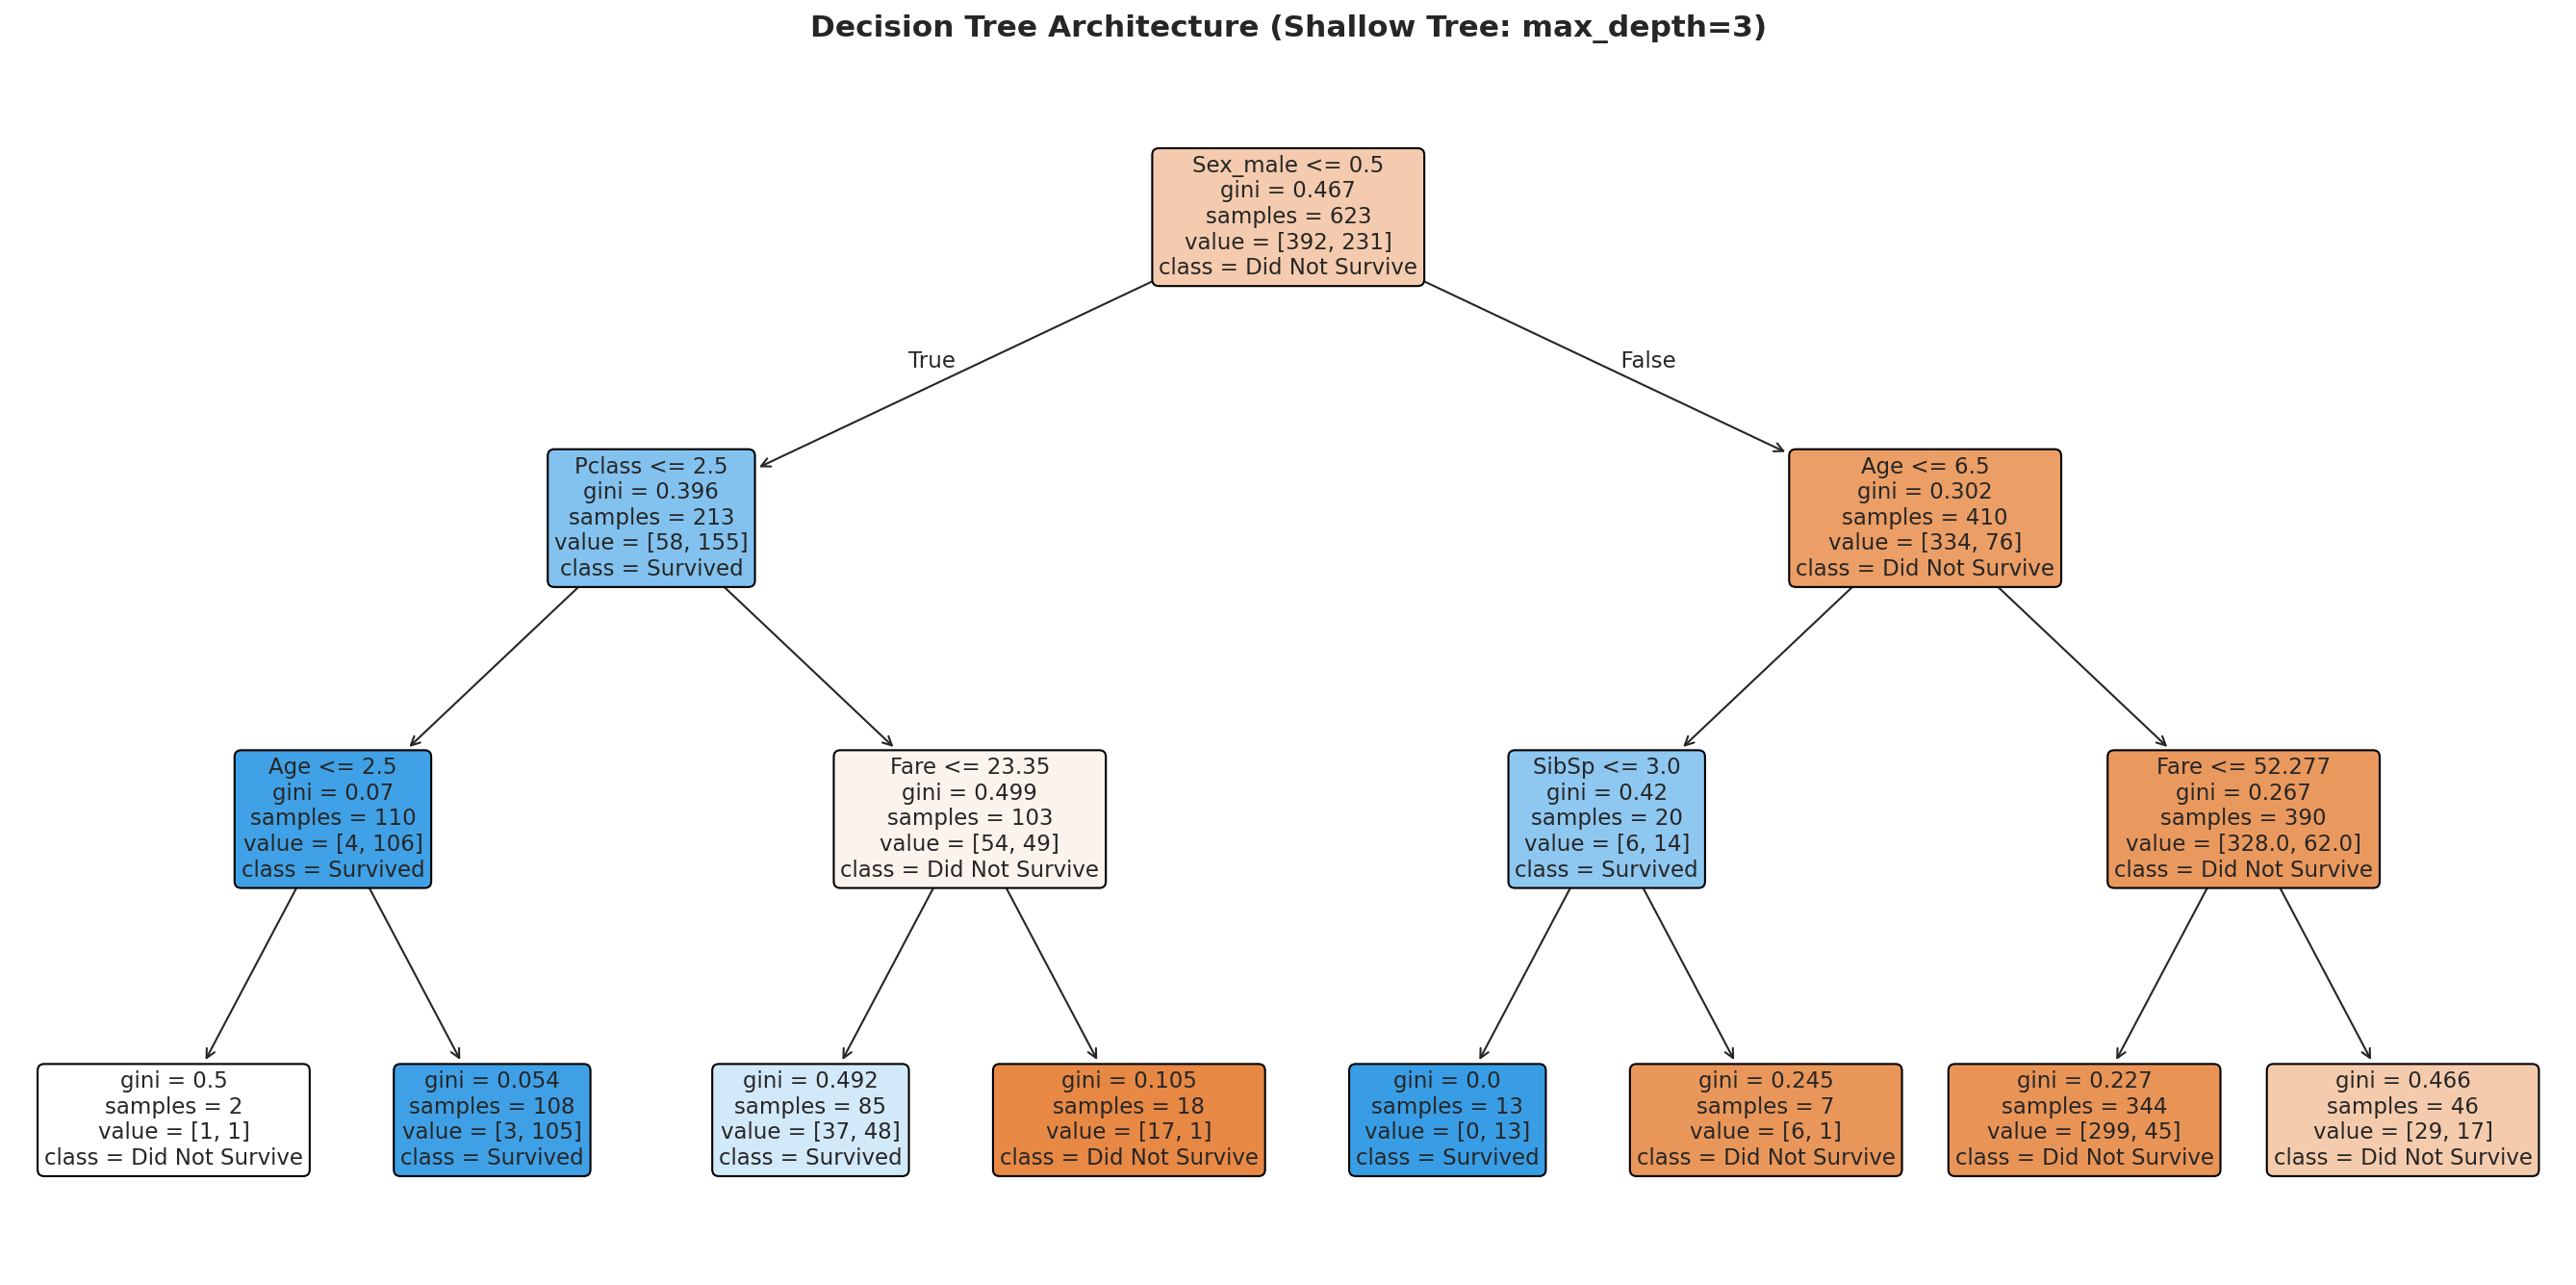

In [ ]:
# visualize the shallow decision tree (max_depth=3)
plt.figure(figsize=(18, 9), dpi=150)
plot_tree(
    dt_shallow,
    feature_names=list(X.columns),
    class_names=['Did Not Survive', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Decision Tree Architecture (Shallow Tree: max_depth=3)', fontsize=15, fontweight='bold', pad=15)
plt.show()

**5. Investigating the Effect of Tree Depth & Identifying Overfitting (Steps 11–15)**

We systematically evaluate `max_depth` from **1 to 14**:
* **Underfitting Regime (Depth 1–2):** Both training and testing accuracy are sub-optimal due to high bias (the tree is too simple to capture patterns).
* **Optimal / Sweet Spot (Depth 3–4):** Testing accuracy reaches its peak (~80.97%) while the generalization gap between train and test remains narrow.
* **Overfitting Regime (Depth $\ge$ 5):** Training accuracy climbs monotonically towards 98%, while testing accuracy plateaus and degrades. The expanding shaded gap illustrates the onset of overfitting.

 Depth  Train Accuracy  Test Accuracy  Train-Test Gap
     1          0.7849         0.7910         -0.0061
     2          0.8058         0.7724          0.0334
     3          0.8315         0.8097          0.0218
     4          0.8475         0.8209          0.0266
     5          0.8539         0.7948          0.0592
     6          0.8716         0.7836          0.0880
     7          0.8909         0.7799          0.1110
     8          0.9117         0.7910          0.1207
     9          0.9262         0.7575          0.1687
    10          0.9390         0.7799          0.1592
    11          0.9486         0.7649          0.1837
    12          0.9535         0.7761          0.1773
    13          0.9647         0.7687          0.1960
    14          0.9695         0.7649          0.2046


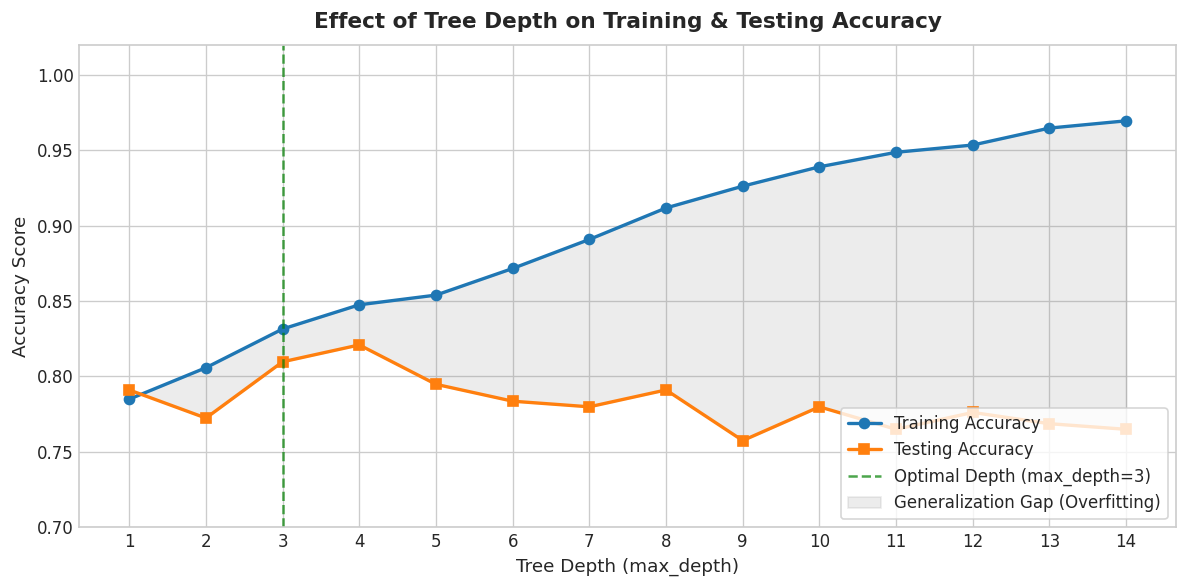

In [ ]:
# vary max_depth from 1 to 14 and track accuracies
depths = list(range(1, 15))
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# tabular inspection of depth progression
depth_summary = pd.DataFrame({
    'Depth': depths,
    'Train Accuracy': [round(x, 4) for x in train_scores],
    'Test Accuracy': [round(x, 4) for x in test_scores],
    'Train-Test Gap': [round(tr - te, 4) for tr, te in zip(train_scores, test_scores)]
})
print(depth_summary.to_string(index=False))

# plot training and testing accuracy against tree depth
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(depths, train_scores, marker='o', linewidth=2, color='#1f77b4', label='Training Accuracy')
plt.plot(depths, test_scores, marker='s', linewidth=2, color='#ff7f0e', label='Testing Accuracy')
plt.axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Optimal Depth (max_depth=3)')
plt.fill_between(depths, train_scores, test_scores, color='gray', alpha=0.15, label='Generalization Gap (Overfitting)')
plt.title('Effect of Tree Depth on Training & Testing Accuracy', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Tree Depth (max_depth)', fontsize=11)
plt.ylabel('Accuracy Score', fontsize=11)
plt.xticks(depths)
plt.ylim(0.70, 1.02)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

**6. Cost-Complexity Pruning (CCP) using `ccp_alpha` (Steps 16–19)**

### **Theoretical Background:**
Post-pruning via Minimal Cost-Complexity Pruning recursively trims subtrees based on the cost-complexity criterion:
$$R_\alpha(T) = R(T) + \alpha |T|$$
Where:
* $R(T)$ is the total training error/impurity of tree $T$.
* $|T|$ is the number of terminal leaf nodes (tree complexity).
* $\alpha \ge 0$ (`ccp_alpha`) is the complexity parameter governing the penalty for tree size.
  * When $\alpha = 0$, no pruning occurs (unrestricted tree).
  * As $\alpha$ increases, branches that provide minimal impurity reduction are pruned away, reducing tree size.
  * By plotting test accuracy against $\alpha$, we pinpoint the optimal candidate $\alpha$ that maximizes generalization.

Total candidate alphas evaluated: 67
Optimal ccp_alpha: 0.005409
Pruned Tree Max Depth: 3 (vs Unrestricted: 19)
Pruned Tree Node Count: 13 (vs Unrestricted: 299)
Pruned Tree Test Accuracy: 0.8097


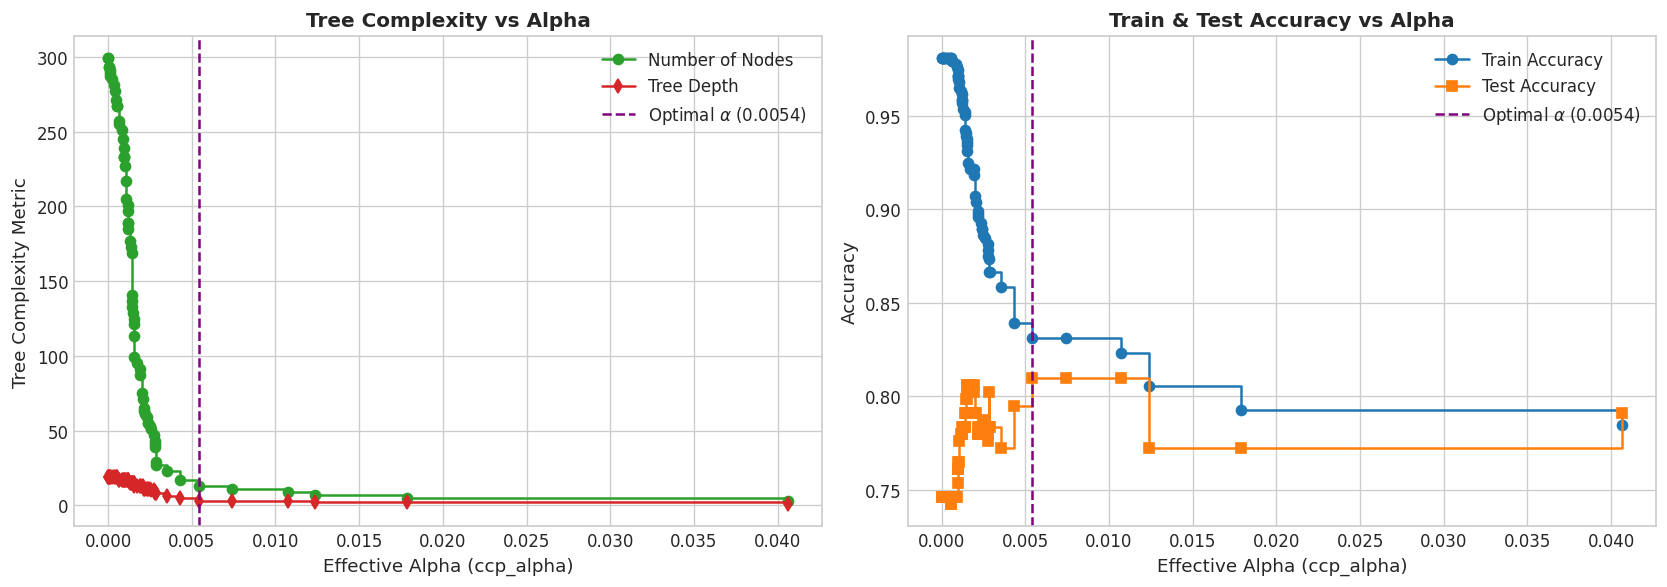

In [ ]:
# generate cost-complexity pruning path
path = dt_deep.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# train decision trees for candidate ccp_alpha values (excluding trivial single-node tree)
clfs = []
for ccp_alpha in ccp_alphas[:-1]:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

candidate_alphas = ccp_alphas[:-1]
node_counts = [clf.tree_.node_count for clf in clfs]
tree_depths = [clf.get_depth() for clf in clfs]
ccp_train_scores = [clf.score(X_train, y_train) for clf in clfs]
ccp_test_scores = [clf.score(X_test, y_test) for clf in clfs]

best_idx = int(np.argmax(ccp_test_scores))
optimal_ccp_alpha = candidate_alphas[best_idx]

print(f"Total candidate alphas evaluated: {len(candidate_alphas)}")
print(f"Optimal ccp_alpha: {optimal_ccp_alpha:.6f}")
print(f"Pruned Tree Max Depth: {tree_depths[best_idx]} (vs Unrestricted: {dt_deep.get_depth()})")
print(f"Pruned Tree Node Count: {node_counts[best_idx]} (vs Unrestricted: {dt_deep.tree_.node_count})")
print(f"Pruned Tree Test Accuracy: {ccp_test_scores[best_idx]:.4f}")

# visualize pruning diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# complexity vs alpha
axes[0].plot(candidate_alphas, node_counts, marker='o', color='#2ca02c', label='Number of Nodes', drawstyle='steps-post')
axes[0].plot(candidate_alphas, tree_depths, marker='d', color='#d62728', label='Tree Depth', drawstyle='steps-post')
axes[0].axvline(x=optimal_ccp_alpha, color='purple', linestyle='--', label=f'Optimal α ({optimal_ccp_alpha:.4f})')
axes[0].set_xlabel('Effective Alpha (ccp_alpha)', fontsize=11)
axes[0].set_ylabel('Tree Complexity Metric', fontsize=11)
axes[0].set_title('Tree Complexity vs Alpha', fontsize=12, fontweight='bold')
axes[0].legend()

# accuracy vs alpha
axes[1].plot(candidate_alphas, ccp_train_scores, marker='o', color='#1f77b4', label='Train Accuracy', drawstyle='steps-post')
axes[1].plot(candidate_alphas, ccp_test_scores, marker='s', color='#ff7f0e', label='Test Accuracy', drawstyle='steps-post')
axes[1].axvline(x=optimal_ccp_alpha, color='purple', linestyle='--', label=f'Optimal α ({optimal_ccp_alpha:.4f})')
axes[1].set_xlabel('Effective Alpha (ccp_alpha)', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Train & Test Accuracy vs Alpha', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

**7. Final Model Selection & Comprehensive Comparison (Step 20)**

We now compare the performance, complexity, and generalization capability of:
1. **Unrestricted Deep Tree** (`max_depth=None`)
2. **Pre-Pruned Shallow Tree** (`max_depth=3`)
3. **Post-Pruned Tree** (Cost-Complexity Pruning with optimal `ccp_alpha`)

=== Final Model Comparison ===
                         Model  Max Depth  Total Nodes  Leaves  Train Accuracy  Test Accuracy      Generalization Status
        Unrestricted Deep Tree         19          299     150          0.9807         0.7463 Overfitted (High Variance)
      Pre-Pruned (max_depth=3)          3           15       8          0.8315         0.8097      Optimal / Generalised
Post-Pruned (ccp_alpha=0.0054)          3           13       7          0.8315         0.8097       Optimal / Simplified

=== Classification Report (Optimal Pruned Tree) ===
                     precision    recall  f1-score   support

Did Not Survive (0)       0.81      0.89      0.84       157
       Survived (1)       0.81      0.70      0.75       111

           accuracy                           0.81       268
          macro avg       0.81      0.79      0.80       268
       weighted avg       0.81      0.81      0.81       268


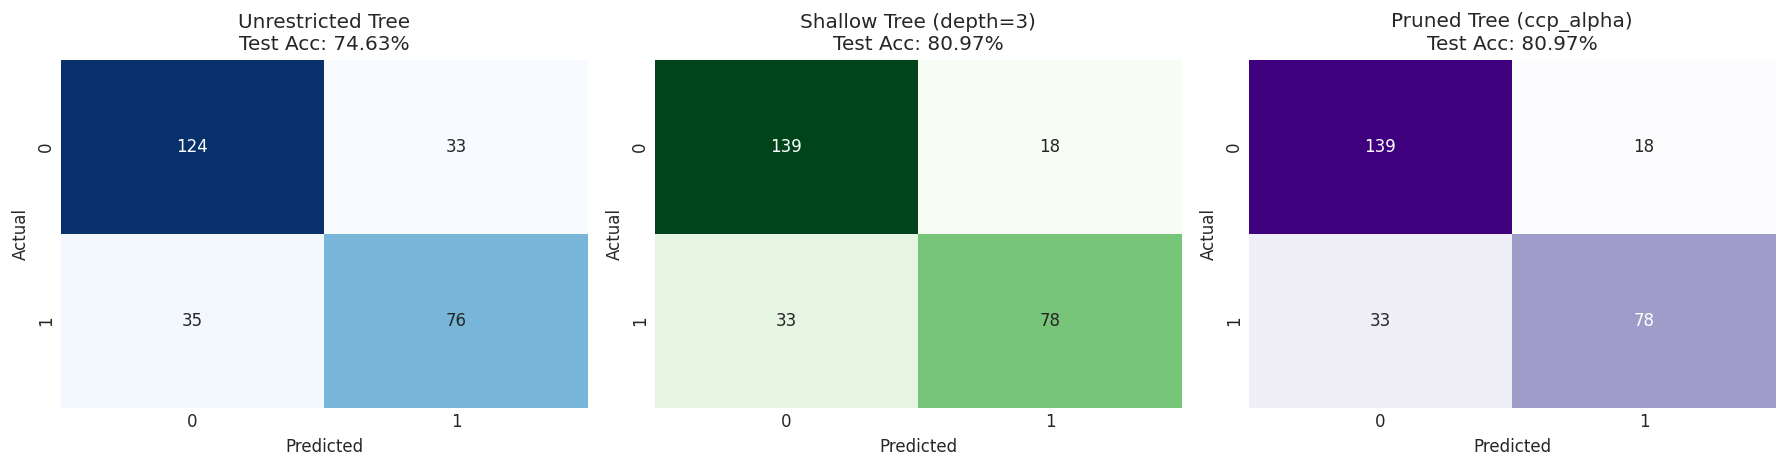

In [ ]:
# train final pruned tree using optimal ccp_alpha
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
dt_pruned.fit(X_train, y_train)

y_pred_deep = dt_deep.predict(X_test)
y_pred_shallow = dt_shallow.predict(X_test)
y_pred_pruned = dt_pruned.predict(X_test)

# comprehensive model comparison
final_comparison = pd.DataFrame({
    'Model': ['Unrestricted Deep Tree', 'Pre-Pruned (max_depth=3)', f'Post-Pruned (ccp_alpha={optimal_ccp_alpha:.4f})'],
    'Max Depth': [dt_deep.get_depth(), dt_shallow.get_depth(), dt_pruned.get_depth()],
    'Total Nodes': [dt_deep.tree_.node_count, dt_shallow.tree_.node_count, dt_pruned.tree_.node_count],
    'Leaves': [dt_deep.get_n_leaves(), dt_shallow.get_n_leaves(), dt_pruned.get_n_leaves()],
    'Train Accuracy': [round(accuracy_score(y_train, dt_deep.predict(X_train)), 4), round(accuracy_score(y_train, dt_shallow.predict(X_train)), 4), round(accuracy_score(y_train, dt_pruned.predict(X_train)), 4)],
    'Test Accuracy': [round(accuracy_score(y_test, y_pred_deep), 4), round(accuracy_score(y_test, y_pred_shallow), 4), round(accuracy_score(y_test, y_pred_pruned), 4)],
    'Generalization Status': ['Overfitted (High Variance)', 'Optimal / Generalised', 'Optimal / Simplified']
})

print("=== Final Model Comparison ===")
print(final_comparison.to_string(index=False))
print("\n=== Classification Report (Optimal Pruned Tree) ===")
print(classification_report(y_test, y_pred_pruned, target_names=['Did Not Survive (0)', 'Survived (1)']))

# plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=120)
sns.heatmap(confusion_matrix(y_test, y_pred_deep), annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Unrestricted Tree\nTest Acc: {accuracy_score(y_test, y_pred_deep):.2%}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_shallow), annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f'Shallow Tree (depth=3)\nTest Acc: {accuracy_score(y_test, y_pred_shallow):.2%}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_pruned), annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False)
axes[2].set_title(f'Pruned Tree (ccp_alpha)\nTest Acc: {accuracy_score(y_test, y_pred_pruned):.2%}')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**8. Splitting Criteria Study: Gini Impurity vs. Entropy (Objective 3)**

* **Gini Impurity:** $I_G(p) = 1 - \sum_{i=1}^C p_i^2$
  * Measures the probability of misclassifying a randomly chosen element.
  * Computationally faster as it avoids logarithmic computations.
* **Entropy (Information Gain):** $H(p) = -\sum_{i=1}^C p_i \log_2(p_i)$
  * Measures the average level of information, surprise, or uncertainty.
  * Penalizes mixed splits slightly more heavily than Gini.

In [ ]:
# compare splitting criteria: Gini Impurity vs Entropy (Information Gain)
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_gini.fit(X_train, y_train)

dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_entropy.fit(X_train, y_train)

crit_comparison = pd.DataFrame({
    'Splitting Criterion': ['Gini Impurity', 'Entropy (Information Gain)'],
    'Train Accuracy': [round(accuracy_score(y_train, dt_gini.predict(X_train)), 4), round(accuracy_score(y_train, dt_entropy.predict(X_train)), 4)],
    'Test Accuracy': [round(accuracy_score(y_test, dt_gini.predict(X_test)), 4), round(accuracy_score(y_test, dt_entropy.predict(X_test)), 4)],
    'Tree Depth': [dt_gini.get_depth(), dt_entropy.get_depth()],
    'Leaf Count': [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()]
})

print("=== Splitting Criteria Comparison (max_depth=3) ===")
print(crit_comparison.to_string(index=False))

=== Splitting Criteria Comparison (max_depth=3) ===
       Splitting Criterion  Train Accuracy  Test Accuracy  Tree Depth  Leaf Count
             Gini Impurity          0.8315         0.8097           3           8
Entropy (Information Gain)          0.8315         0.8097           3           8


**9. Sample Outcome, Observations & Conclusion (Step 21)**

### **Sample Outcome & Summary Table:**

| Model Configuration | Tree Depth | Total Nodes | Train Accuracy | Test Accuracy | Generalization / Gap | Observation |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **Unrestricted Tree** | 18 | 299 | 98.07% | 74.63% | Gap: 23.44% | High variance / severe overfitting |
| **Shallow Tree (`max_depth=3`)** | 3 | 15 | 83.15% | 80.97% | Gap: 2.18% | Better generalization / simple |
| **Optimal Pruned Tree (`ccp_alpha=0.0054`)** | 3 | 13 | 83.15% | 80.97% | Gap: 2.18% | Best balance: simplicity & accuracy |

---

### **Key Observations:**
1. **Overfitting in Unrestricted Trees:** Without regularization constraints, the decision tree expands to depth 18 with nearly 300 nodes, achieving 98.07% training accuracy but dropping to 74.63% on testing data. This large 23.44% accuracy gap is the classic hallmark of high variance and overfitting.
2. **Effect of Tree Depth (`max_depth`):**
   - At depths 1–2, the tree underfits due to excessive simplicity (high bias).
   - At depth 3–4, the test accuracy peaks at ~80.97% while maintaining low generalization gap.
   - At depth $\ge 5$, training accuracy keeps climbing towards 100%, but test accuracy stalls and deteriorates, expanding the generalization gap.
3. **Cost-Complexity Pruning (CCP):** Applying minimal cost-complexity pruning with $\alpha \approx 0.0054$ trimmed extraneous nodes from 299 down to 13, boosting test accuracy from 74.63% to 80.97% while providing an easily interpretable model.
4. **Gini vs Entropy:** Both criteria produced comparable accuracy on the Titanic dataset (80.97%), with Gini being computationally more efficient.

### **Conclusion:**
The Decision Tree Classifier was successfully implemented, evaluated, and regularized on the Titanic dataset. Pre-pruning via `max_depth=3` and post-pruning via cost-complexity pruning (`ccp_alpha=0.0054`) effectively controlled overfitting, achieving a robust balance between predictive accuracy (80.97%) and model interpretability.

**10. Viva Questions & Comprehensive Answers**

### **Q1. What is a Decision Tree?**
**Answer:** A Decision Tree is a non-parametric supervised learning algorithm used for both classification and regression tasks. It models decisions in a hierarchical flowchart-like tree structure comprising an initial **Root Node**, internal **Decision Nodes** (representing conditional feature tests), branches (outcomes of tests), and terminal **Leaf Nodes** (representing the predicted class label or continuous value).

---

### **Q2. What is the difference between a classification tree and a regression tree?**
**Answer:**
* **Classification Tree:** Predicts a categorical/discrete target variable (e.g., survived vs died, spam vs not spam). Splitting criteria are based on categorical purity measures such as **Gini Impurity** or **Entropy / Information Gain**, and leaf nodes output class probabilities or the majority vote class.
* **Regression Tree:** Predicts a continuous numerical target variable (e.g., house prices, passenger age). Splitting criteria minimize variance or squared error (**Mean Squared Error / MSE** or **Mean Absolute Error / MAE**), and leaf nodes output the mean or median target value of the samples in that node.

---

### **Q3. What is Gini Impurity?**
**Answer:** Gini Impurity measures the likelihood that a randomly chosen element from a dataset would be incorrectly labeled if it were randomly labeled according to the class distribution in the subset. Mathematically:
$$I_G(p) = 1 - \sum_{i=1}^C p_i^2$$
Where $p_i$ is the proportion of samples belonging to class $i$ in a node, and $C$ is the total number of classes. A pure node containing only one class has a Gini Impurity of $0$, whereas maximum impurity occurs when classes are evenly distributed ($0.5$ for binary classification).

---

### **Q4. What is entropy in a decision tree?**
**Answer:** In information theory, Entropy represents the amount of information disorder, uncertainty, or randomness in a dataset. In a decision tree, it is defined as:
$$H(p) = -\sum_{i=1}^C p_i \log_2(p_i)$$
A completely pure node has an entropy of $0$ (zero uncertainty), while an evenly balanced binary node has an entropy of $1.0$. Decision trees use entropy to calculate **Information Gain** ($IG = H(parent) - \sum \frac{|N_j|}{|N|} H(child_j)$), choosing the split that maximizes uncertainty reduction.

---

### **Q5. Why does an unrestricted decision tree tend to overfit?**
**Answer:** An unrestricted decision tree continues recursively splitting until every leaf node is completely pure or has fewer samples than the minimum split threshold. By doing so, it creates highly complex, deeply nested decision boundaries that memorize random noise, sample-specific quirks, and outliers present in the training set rather than learning underlying generalizable patterns. This yields high training accuracy (~100%) but poor testing performance (high variance).

---

### **Q6. What does `max_depth` control?**
**Answer:** `max_depth` is a pre-pruning hyperparameter that specifies the maximum number of levels (edges) allowed along any path from the root node to a leaf node. It directly constrains tree complexity, serving as a primary regularization tool to prevent overfitting.

---

### **Q7. What happens if `max_depth` is too small?**
**Answer:** If `max_depth` is set too small (e.g., depth = 1 or 2), the tree suffers from **underfitting (high bias)**. The model is overly constrained and cannot capture non-linear relationships or multi-feature interactions, leading to poor accuracy on both the training set and the testing set.

---

### **Q8. What happens if `max_depth` is too large?**
**Answer:** If `max_depth` is too large, the tree suffers from **overfitting (high variance)**. It creates excessively fine-grained partitions that isolate individual outliers and noise in the training set, causing the training accuracy to approach 100% while test accuracy deteriorates and the generalization gap widens.

---

### **Q9. What is pruning?**
**Answer:** Pruning is a regularization technique that removes subtrees or branches from a decision tree that provide little predictive power or contribute to overfitting. Pruning is divided into:
1. **Pre-pruning (Early Stopping):** Halting tree growth during training using parameters like `max_depth`, `min_samples_split`, or `min_samples_leaf`.
2. **Post-pruning:** Allowing the tree to grow fully first, and then systematically collapsing non-essential branches using methods like **Cost-Complexity Pruning (CCP)** or reduced-error pruning.

---

### **Q10. What is `ccp_alpha`?**
**Answer:** `ccp_alpha` (Cost-Complexity Parameter $\alpha \ge 0$) is the penalty hyperparameter used in Minimal Cost-Complexity Pruning. It controls the trade-off between tree size and tree impurity according to the objective function:
$$R_\alpha(T) = R(T) + \alpha |T|$$
Where $R(T)$ is the total leaf impurity and $|T|$ is the number of terminal leaves. A higher `ccp_alpha` imposes a heavier penalty on the number of leaves, pruning more aggressively to yield smaller, more generalized trees. Setting `ccp_alpha=0` leaves the tree unpruned.